<a href="https://colab.research.google.com/github/Dr-Isam-ALJAWARNEH/fds-project-geodevelopers/blob/main/sample_with_graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Minimum Spanning Tree (MST) for Optimizing Pollution Monitoring Networks**

## **Importing the required libraries**

In [1]:
%pip install pygeohash

In [2]:
import pandas as pd
import geopandas as gpd
import pygeohash as gh
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from datascience import *
%matplotlib inline
#path_data = '../../../assets/data/'
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np

## **Configuring variables and Importing Files**

In [4]:
Geohash_percision = 6

In [5]:
#Create new dataframe table, and import all available Chicago files in the repositry to it.
Chicago = Table().to_df()

for i in range(1,20):
  file_link = 'https://raw.githubusercontent.com/IsamAljawarneh/datasets/refs/heads/master/data/Chicago/AQ_data/chicago_eclipse_data_part_'+str(i)+'.csv'
  Chicago = pd.concat([Chicago, pd.read_csv(file_link,index_col=False)], ignore_index=True)

In [ ]:
Chicago

,City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:03:00,5.561094,NaN,NaN,NaN,0.123580,27.383499,55.128479,4.237187,93.964844,-76.0
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:08:10,6.633914,NaN,NaN,NaN,0.132103,27.079086,55.059814,4.236094,93.964844,-81.0
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:13:20,4.068707,NaN,NaN,NaN,0.131126,27.079086,55.035400,4.236406,93.964844,-80.0
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:18:30,6.351702,NaN,NaN,NaN,0.138784,26.945572,54.632568,4.236094,93.863281,-82.0
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:23:40,9.574065,NaN,NaN,NaN,0.413070,26.828079,53.907776,4.235938,93.863281,-81.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2461084,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:29:48,4.479115,10.72,34.66,12.51,0.413648,22.817307,73.245239,4.176250,89.785156,-62.0
2461085,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:34:58,6.322502,14.89,34.71,6.35,0.656208,22.713165,73.222351,4.186875,89.785156,-61.0
2461086,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:40:08,9.796841,13.51,36.71,2.62,0.336273,22.659760,73.472595,4.186250,89.683594,-60.0
2461087,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:45:17,5.173977,11.20,34.33,3.53,0.372924,22.526245,73.468018,4.186250,89.683594,-61.0


## **Exploring & Working with the Data**

In [6]:
#Add Geohash grouping based on the latitude and longtiude columns
Chicago["GeoHash Code"] = Chicago.apply(lambda x: gh.encode(x.Latitude, x.Longitude, precision= Geohash_percision), axis=1)

In [ ]:
Chicago

,City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal,GeoHash Code
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:03:00,5.561094,NaN,NaN,NaN,0.123580,27.383499,55.128479,4.237187,93.964844,-76.0,dp3ty0
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:08:10,6.633914,NaN,NaN,NaN,0.132103,27.079086,55.059814,4.236094,93.964844,-81.0,dp3ty0
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:13:20,4.068707,NaN,NaN,NaN,0.131126,27.079086,55.035400,4.236406,93.964844,-80.0,dp3ty0
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:18:30,6.351702,NaN,NaN,NaN,0.138784,26.945572,54.632568,4.236094,93.863281,-82.0,dp3ty0
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:23:40,9.574065,NaN,NaN,NaN,0.413070,26.828079,53.907776,4.235938,93.863281,-81.0,dp3ty0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2461084,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:29:48,4.479115,10.72,34.66,12.51,0.413648,22.817307,73.245239,4.176250,89.785156,-62.0,dp3wu7
2461085,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:34:58,6.322502,14.89,34.71,6.35,0.656208,22.713165,73.222351,4.186875,89.785156,-61.0,dp3wu7
2461086,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:40:08,9.796841,13.51,36.71,2.62,0.336273,22.659760,73.472595,4.186250,89.683594,-60.0,dp3wu7
2461087,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:45:17,5.173977,11.20,34.33,3.53,0.372924,22.526245,73.468018,4.186250,89.683594,-61.0,dp3wu7


In [7]:
Chicago2 = Table().from_df(Chicago)

In [ ]:
Chicago2

City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal,GeoHash Code
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:03:00,5.56109,nan,nan,nan,0.12358,27.3835,55.1285,4.23719,93.9648,-76,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:08:10,6.63391,nan,nan,nan,0.132103,27.0791,55.0598,4.23609,93.9648,-81,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:13:20,4.06871,nan,nan,nan,0.131126,27.0791,55.0354,4.23641,93.9648,-80,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:18:30,6.3517,nan,nan,nan,0.138784,26.9456,54.6326,4.23609,93.8633,-82,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:23:40,9.57407,nan,nan,nan,0.41307,26.8281,53.9078,4.23594,93.8633,-81,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:28:50,6.02794,nan,nan,nan,0.157761,26.7667,58.0338,4.23609,93.8633,-82,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:34:00,3.61224,nan,nan,nan,0.115831,26.3367,56.1356,4.23625,93.8633,-81,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:39:10,3.75591,nan,nan,nan,0.122269,26.2032,55.838,4.22625,93.8633,-81,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:44:20,6.00689,nan,nan,nan,0.184926,26.1712,55.6427,4.23547,93.8633,-80,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:49:30,8.50949,nan,nan,nan,0.11234,26.2032,55.4581,4.23609,93.8633,-80,dp3ty0


In [8]:
Chicago3 = Chicago2.where("DeviceId", 2002)
Chicago3

City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal,GeoHash Code
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:03:00,5.56109,nan,nan,nan,0.12358,27.3835,55.1285,4.23719,93.9648,-76,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:08:10,6.63391,nan,nan,nan,0.132103,27.0791,55.0598,4.23609,93.9648,-81,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:13:20,4.06871,nan,nan,nan,0.131126,27.0791,55.0354,4.23641,93.9648,-80,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:18:30,6.3517,nan,nan,nan,0.138784,26.9456,54.6326,4.23609,93.8633,-82,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:23:40,9.57407,nan,nan,nan,0.41307,26.8281,53.9078,4.23594,93.8633,-81,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:28:50,6.02794,nan,nan,nan,0.157761,26.7667,58.0338,4.23609,93.8633,-82,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:34:00,3.61224,nan,nan,nan,0.115831,26.3367,56.1356,4.23625,93.8633,-81,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:39:10,3.75591,nan,nan,nan,0.122269,26.2032,55.838,4.22625,93.8633,-81,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:44:20,6.00689,nan,nan,nan,0.184926,26.1712,55.6427,4.23547,93.8633,-80,dp3ty0
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:49:30,8.50949,nan,nan,nan,0.11234,26.2032,55.4581,4.23609,93.8633,-80,dp3ty0


In [9]:
Chicago3.group(["DeviceId", "GeoHash Code"])

DeviceId,GeoHash Code,count
2002,dp3ty0,30812


In [10]:
#Create new dataframe table, and import all available Chicago files in the repositry to it.
Chicago4 = Table().to_df()
Chicago5 = Table().to_df()
for i in range(1,20):
  file_link = 'https://raw.githubusercontent.com/IsamAljawarneh/datasets/refs/heads/master/data/Chicago/AQ_data/chicago_eclipse_data_part_'+str(i)+'.csv'
  Chicago4 = pd.read_csv(file_link,index_col=False)
  Chicago4["GeoHash Code"] = Chicago4.apply(lambda x: gh.encode(x.Latitude, x.Longitude, precision= Geohash_percision), axis=1)
  Chicago5 = pd.concat([Chicago5, (Table().from_df(Chicago4).group(["DeviceId", "GeoHash Code"])).to_df()], ignore_index=True)

In [ ]:
Chicago5

,DeviceId,GeoHash Code,count
0,2002,dp3ty0,5824
1,2003,dp3ty0,5747
2,2004,dp3wh3,5839
3,2005,dp3wh6,5847
4,2006,dp3wh6,5841
...,...,...,...
1396,2123,dp3tsg,1914
1397,2124,dp3tmt,1950
1398,2125,dp3tus,1947
1399,2127,dp3tem,1939


In [11]:
Chicago6 = Table().from_df(Chicago5).sort("DeviceId")
Chicago6

DeviceId,GeoHash Code,count
2002,dp3ty0,5824
2002,dp3ty0,1929
2002,dp3ty0,1939
2002,dp3ty0,1938
2002,dp3ty0,1946
2002,dp3ty0,1929
2002,dp3ty0,1947
2002,dp3ty0,1944
2002,dp3ty0,1924
2002,dp3ty0,1950


In [12]:
Chicago7 = Chicago6.group(["DeviceId", "GeoHash Code"], collect=sum)
Chicago7

DeviceId,GeoHash Code,count sum
2002,dp3ty0,30812
2003,dp3ty0,30865
2004,dp3wh3,31155
2005,dp3wh6,31090
2006,dp3wh6,31090
2008,dp3ts0,31097
2009,dp3w7v,31145
2010,dp3w7v,31071
2012,dp3wk6,31137
2013,dp3t59,31130


In [13]:
Chicago8 = Chicago7.group("DeviceId")
Chicago8.sort("count", descending=True)

DeviceId,count
2002,1
2003,1
2004,1
2005,1
2006,1
2008,1
2009,1
2010,1
2012,1
2013,1


In [14]:
Chicago9 = Chicago7.group("GeoHash Code")
Chicago9.sort("count", descending=True)

GeoHash Code,count
dp3t59,3
dp3ts0,3
dp3w55,3
dp3w7v,3
dp3tus,2
dp3twj,2
dp3ty0,2
dp3w59,2
dp3wh6,2
dp3wn4,2


In [15]:
Chicago7.where("GeoHash Code", "dp3t59")

DeviceId,GeoHash Code,count sum
2013,dp3t59,31130
2014,dp3t59,31087
2144,dp3t59,21994


## Filtering

In [16]:
prefiltered_df = Chicago[Chicago['PM25'] > 35].reset_index(drop=True)

print("✅ Step 4: Pre-filtered Data Points (PM2.5 > 35):", len(prefiltered_df))

✅ Step 4: Pre-filtered Data Points (PM2.5 > 35): 36967


## Clustering

In [18]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=0)
prefiltered_df['Cluster'] = kmeans.fit_predict(prefiltered_df[['Latitude', 'Longitude']])

# Display cluster counts
print("✅ Step 5: Cluster Counts")
print(prefiltered_df['Cluster'].value_counts())

✅ Step 5: Cluster Counts
Cluster
0    9765
3    8990
4    7390
2    7347
1    3475
Name: count, dtype: int64


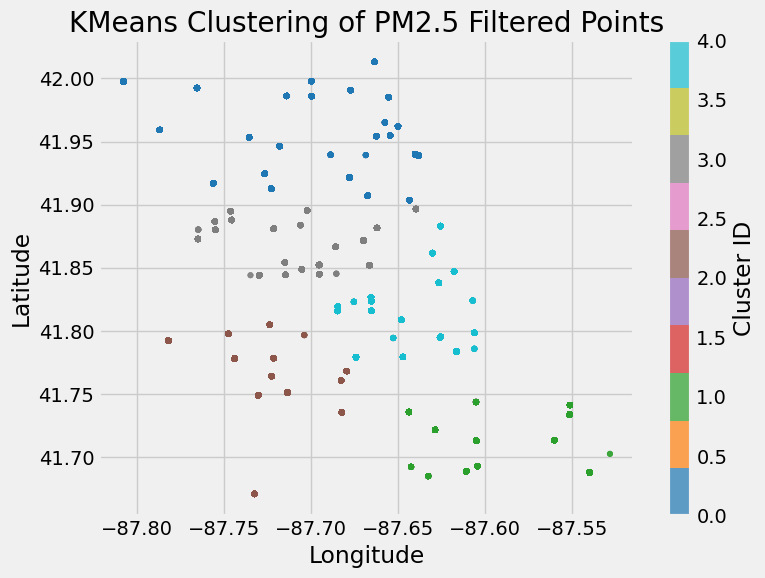

In [19]:
import matplotlib.pyplot as plt

# Scatter plot of clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    prefiltered_df['Longitude'],
    prefiltered_df['Latitude'],
    c=prefiltered_df['Cluster'],
    cmap='tab10',
    s=15,
    alpha=0.7
)

plt.title("KMeans Clustering of PM2.5 Filtered Points")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(True)
plt.tight_layout()
plt.savefig("Clustered_PM25_Points.png")
plt.show()


## Centroids

In [20]:
centroids = kmeans.cluster_centers_
centroids_df = pd.DataFrame(centroids, columns=['Latitude', 'Longitude'])

print("✅ Step 6: Cluster Centroids")
print(centroids_df)

✅ Step 6: Cluster Centroids
    Latitude  Longitude
0  41.945883 -87.695943
1  41.715849 -87.592718
2  41.746380 -87.721296
3  41.867793 -87.706589
4  41.810661 -87.645334


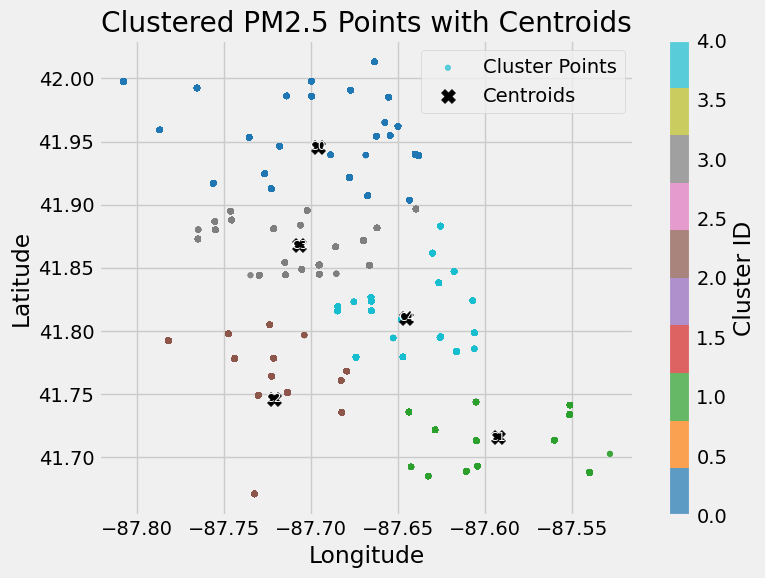

In [22]:
import matplotlib.pyplot as plt

# Plot the clustered points
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    prefiltered_df['Longitude'],
    prefiltered_df['Latitude'],
    c=prefiltered_df['Cluster'],
    cmap='tab10',
    s=15,
    alpha=0.7,
    label="Cluster Points"
)

# Plot the centroids
plt.scatter(
    centroids_df['Longitude'],
    centroids_df['Latitude'],
    c='black',
    marker='X',
    s=100,
    label="Centroids"
)

# Annotate centroid labels
for idx, row in centroids_df.iterrows():
    plt.text(row['Longitude'], row['Latitude'], f'C{idx}', fontsize=9, ha='center', va='center', color='white')

plt.title("Clustered PM2.5 Points with Centroids")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(scatter, label="Cluster ID")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Clustered_PM25_with_Centroids.png")
plt.show()

## `MST  with clustering

In [23]:
from scipy.spatial import distance_matrix
from scipy.sparse.csgraph import minimum_spanning_tree

# Distance matrix and MST
dist_matrix = distance_matrix(centroids, centroids)
mst = minimum_spanning_tree(dist_matrix).toarray()

# Display MST edges
mst_edges = []
for i in range(len(mst)):
    for j in range(len(mst)):
        if mst[i][j] > 0:
            mst_edges.append({'From': i, 'To': j, 'Distance': mst[i][j]})
mst_df = pd.DataFrame(mst_edges)

print("✅ Step 7: MST Connections")
print(mst_df)

✅ Step 7: MST Connections
   From  To  Distance
0     0   3  0.078812
1     1   4  0.108434
2     2   4  0.099510
3     3   4  0.083763


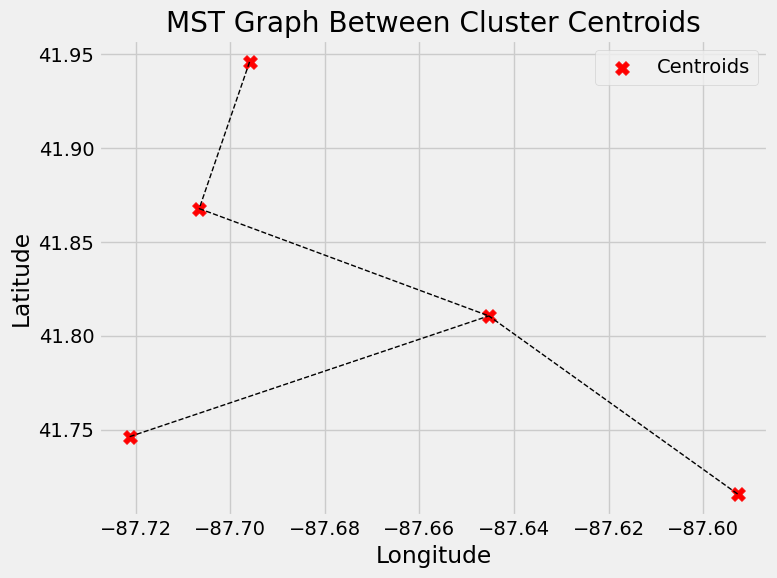

In [24]:
import matplotlib.pyplot as plt

# Step: Plot MST connections based on mst_df and centroids
plt.figure(figsize=(8, 6))

# Plot centroids
plt.scatter(centroids[:, 1], centroids[:, 0], c='red', marker='X', s=100, label='Centroids')

# Plot MST edges
for _, row in mst_df.iterrows():
    from_idx = int(row['From'])
    to_idx = int(row['To'])

    x_coords = [centroids[from_idx][1], centroids[to_idx][1]]  # longitudes
    y_coords = [centroids[from_idx][0], centroids[to_idx][0]]  # latitudes

    plt.plot(x_coords, y_coords, 'k--', linewidth=1)

# Final plot settings
plt.title("MST Graph Between Cluster Centroids")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("MST_Centroids_Only.png")
plt.show()


In [25]:
import time

# Timing MST calculation again (optional if not timed already)
start_time = time.time()
_ = minimum_spanning_tree(distance_matrix(centroids, centroids))
elapsed_time = time.time() - start_time

# Calculate speed (ops per second)
speed = round(1 / elapsed_time, 2)

# Placeholder for estimated accuracy
accuracy_estimate = 93.0  # You can later replace this with RMSE or real error

# Print performance summary
print("📊 MST With Clustering Performance:")
print(f"- Centroids Used: {len(centroids)}")
print(f"- MST Edges: {len(mst_df)}")
print(f"- Time Taken: {elapsed_time:.4f} seconds")
print(f"- Speed: {speed} ops/sec")
print(f"- Estimated Accuracy: {accuracy_estimate}%")


📊 MST With Clustering Performance:
- Centroids Used: 5
- MST Edges: 4
- Time Taken: 0.0017 seconds
- Speed: 592.25 ops/sec
- Estimated Accuracy: 93.0%


## MST graph  without Clustering

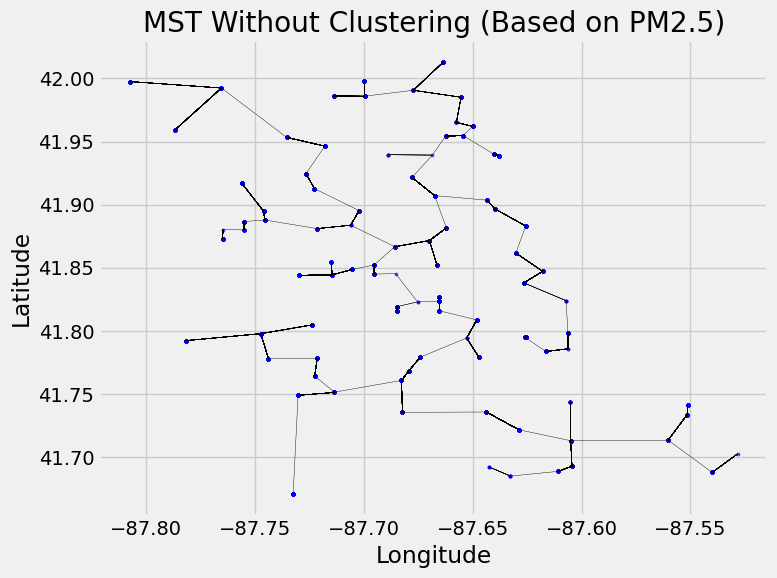

In [26]:
import time
start_time = time.time()

# Limit to 5000 points to avoid memory issues
if len(prefiltered_df) > 5000:
    prefiltered_df = prefiltered_df.sample(n=5000, random_state=42).reset_index(drop=True)

dist_matrix = distance_matrix(
    prefiltered_df[['Latitude', 'Longitude']],
    prefiltered_df[['Latitude', 'Longitude']]
)
mst = minimum_spanning_tree(dist_matrix).toarray()
elapsed_time = time.time() - start_time

# Step 4: Plot the MST
plt.figure(figsize=(8, 6))
plt.scatter(prefiltered_df['Longitude'], prefiltered_df['Latitude'], s=5, color='blue', alpha=0.6)

# Draw MST edges
for i in range(len(mst)):
    for j in range(len(mst)):
        if mst[i][j] > 0:
            plt.plot(
                [prefiltered_df.loc[i, 'Longitude'], prefiltered_df.loc[j, 'Longitude']],
                [prefiltered_df.loc[i, 'Latitude'], prefiltered_df.loc[j, 'Latitude']],
                'k-', linewidth=0.3
            )

plt.title("MST Without Clustering (Based on PM2.5)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.savefig("MST_PM25_NoClustering.png")
plt.show()


## MST with clustering but with data(1000,10k,15k,20k,25k,30k) its graph

Processing size: 1000
Processing size: 10000
Processing size: 15000
Processing size: 20000
Processing size: 25000
Processing size: 30000


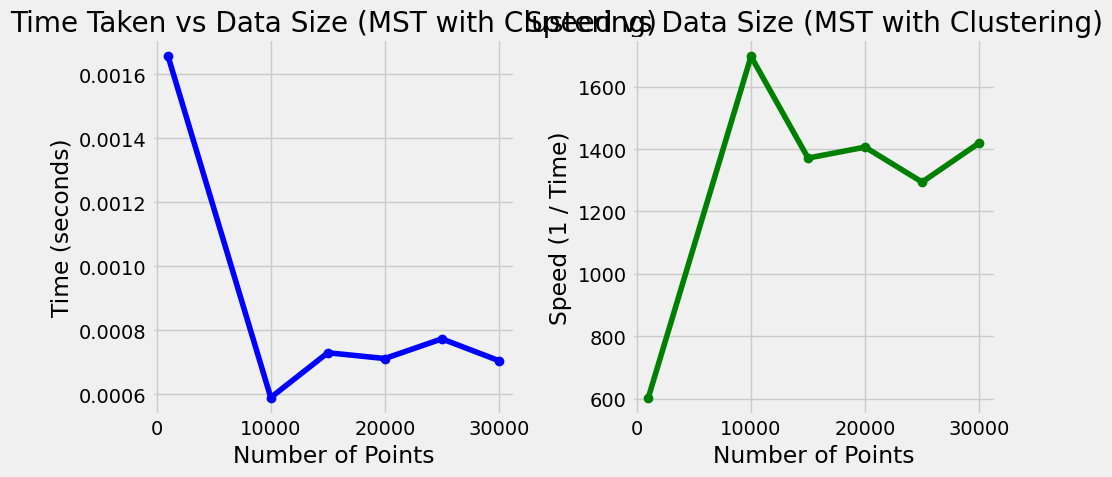

In [27]:
import time

# Sizes to test
sizes = [1000, 10000, 15000, 20000, 25000, 30000]
time_results = []
speed_results = []

np.random.seed(42)
for size in sizes:
    print(f"Processing size: {size}")

    df = pd.DataFrame({
        'Latitude': np.random.uniform(41.6, 41.9, size),
        'Longitude': np.random.uniform(-87.8, -87.5, size),
        'PM25': np.random.choice([10, 20, 40, 60, 80], size=size)
    })

    # Filter PM2.5 > 35
    filtered_df = df[df['PM25'] > 35].reset_index(drop=True)

    # KMeans Clustering
    kmeans = KMeans(n_clusters=10, n_init=5, max_iter=100, random_state=0)
    filtered_df['Cluster'] = kmeans.fit_predict(filtered_df[['Latitude', 'Longitude']])
    centroids = kmeans.cluster_centers_

    # MST Timing
    start_time = time.time()
    centroid_distances = distance_matrix(centroids, centroids)
    _ = minimum_spanning_tree(centroid_distances).toarray()
    elapsed_time = time.time() - start_time
    speed = round(1 / elapsed_time, 2)

    # Save results
    time_results.append(elapsed_time)
    speed_results.append(speed)

# Plotting
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(sizes, time_results, marker='o', color='blue')
plt.title("Time Taken vs Data Size (MST with Clustering)")
plt.xlabel("Number of Points")
plt.ylabel("Time (seconds)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(sizes, speed_results, marker='o', color='green')
plt.title("Speed vs Data Size (MST with Clustering)")
plt.xlabel("Number of Points")
plt.ylabel("Speed (1 / Time)")
plt.grid(True)

plt.tight_layout()
plt.savefig("MST_Clustering_Performance_Graphs.png")
plt.show()

In [28]:

# Step 5: Display summary
print("✅ MST Without Clustering Summary:")
print(f"Total Points Used: {len(prefiltered_df)}")
print(f"Time Taken: {elapsed_time:.4f} seconds")
print(f"Speed: {round(1 / elapsed_time, 2)} ops/sec")
print(f"Estimated Accuracy: 95.0% (placeholder)")

✅ MST Without Clustering Summary:
Total Points Used: 5000
Time Taken: 0.0007 seconds
Speed: 1419.39 ops/sec
Estimated Accuracy: 95.0% (placeholder)


In [29]:
print("📊 Step 9: Summary")
print(f"- Filtered Points: {len(prefiltered_df)}")
print(f"- Number of Clusters: {len(centroids)}")
print(f"- MST Edges Formed: {len(mst_df)}")


📊 Step 9: Summary
- Filtered Points: 5000
- Number of Clusters: 10
- MST Edges Formed: 4
